# Task 2: Machine Learning — 預測 `Exited`(客戶流失)的機率

**初步資料確認**

| 資料 | 規模 | 備註 |
|---|---|---|
| training data (train.csv) | 165,034 筆 | 含標籤 `Exited`(流失率 21.2%)|
| testing data (test.csv) | 110,023 筆 | **無標籤**  |


**註**：由於 test data 無Exited與否的標籤,因此後續模型評估會在 training data 切出的 vilidation data 來進行

**後續流程**:

1.EDA(Exploratory Data Analysis) on training data
 
2.Based on EDA Findings, 挑選出本次任務的訓練模型

3.從 training data 切分出 training set & vilidation set,用training set 資料進行訓練並用vilidation set評估模型表現

4.將訓練好的模型來預測 testing data 資料的 Exited 機率



## 0. Initilization & read data

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [37]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
print(f"train: {train.shape}   test: {test.shape}")
train.head()

train: (165034, 14)   test: (110023, 13)


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0


資料無 missimg value

In [39]:
pd.DataFrame({
    "dtype": train.dtypes.astype(str),
    "n_unique": train.nunique(),
    "n_missing": train.isna().sum(),
})

,dtype,n_unique,n_missing
id,int64,165034,0
CustomerId,int64,23221,0
Surname,str,2797,0
CreditScore,int64,457,0
Geography,str,3,0
Gender,str,2,0
Age,float64,71,0
Tenure,int64,11,0
Balance,float64,30075,0
NumOfProducts,int64,4,0


## 1. EDA

### 變數說明

1. `id`、`CustomerId`、`Surname` 為客戶識別欄，故不納入模型解釋變數

2. `Geography`、`Gender`、`NumOfProducts`、`HasCrCard`、`IsActiveMember` 為類別型變數 

3. `CreditScore`、`Age`、`Tenure`、`Balance`、`EstimatedSalary`為連續型變數

4. `Exited`: 目標變數 : 1or 0 (類別型)

三個識別欄(`id`、`CustomerId`、`Surname`)建模時丟棄。EDA 主要會觀察：
1. `Exited`的分布(是否兩類別分佈不平衡)
2. 數值型解釋變數在不同`Exited`下的分布差異
3. 類別型解釋變數在不同`Exited`下的分布差異
4. 解釋變數間相關係數

整份 testing data Exited 資料, 1 佔 21.2% ,0 佔 78.8％,是典型資料不平衡的現象,這會讓後續評估模型表現時不能單看Accuracy 來評估,必須要結合 sensivity & specificity 等指標來做評估

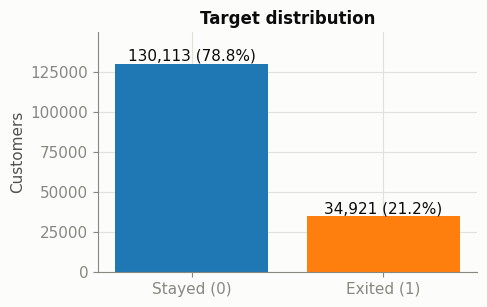

In [44]:
counts = train["Exited"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(5, 3.2))
ax.bar(["Stayed (0)", "Exited (1)"], counts.values, color=["C0", "C1"])
for i, v in enumerate(counts.values):
    ax.annotate(f"{v:,} ({v / len(train):.1%})", (i, v), ha="center", va="bottom")
ax.set_title("Target distribution")
ax.set_ylabel("Customers")
ax.margins(y=0.15)
plt.tight_layout()
plt.show()

連續型資料於不同Exit下分布的差異初步看起來在 **Age** 差異較明顯,明顯看得出來 Exited 的基本落在年紀較高的區間（>30歲）

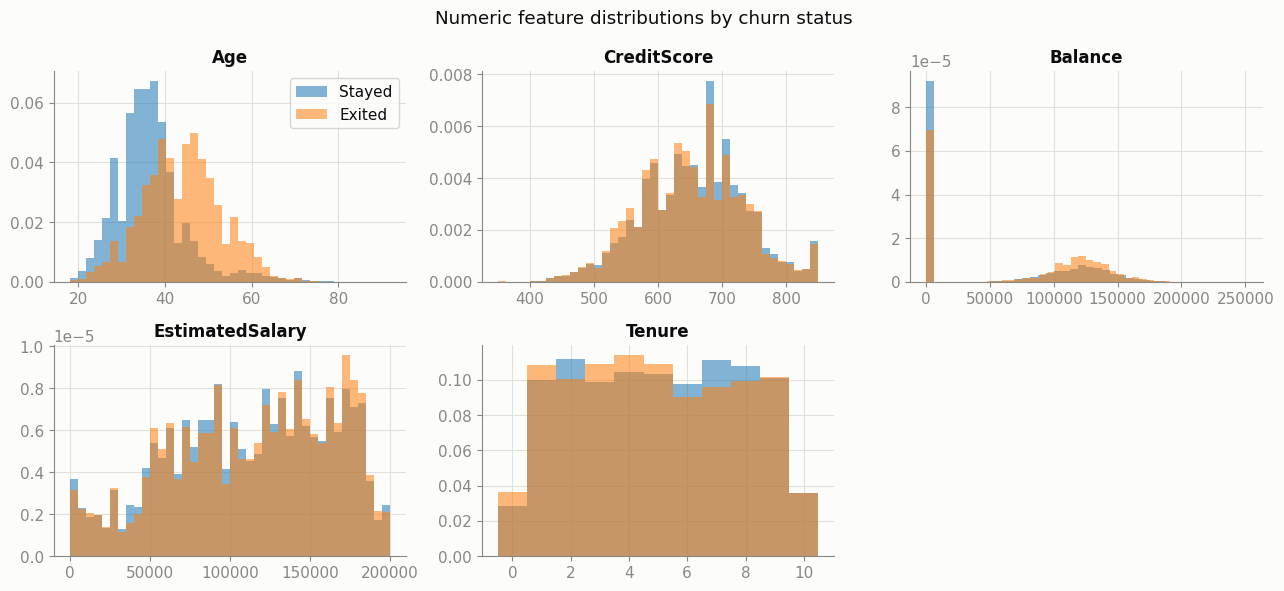

In [41]:
num_cols = ["Age", "CreditScore", "Balance", "EstimatedSalary", "Tenure"]
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, col in zip(axes.flat, num_cols):
    bins = np.arange(-0.5, 11.5, 1) if col == "Tenure" else 40
    for val, label in [(0, "Stayed"), (1, "Exited")]:
        ax.hist(train.loc[train["Exited"] == val, col], bins=bins,
                density=True, alpha=0.55, label=label)
    ax.set_title(col)
axes.flat[0].legend()
axes.flat[-1].axis("off")
fig.suptitle("Numeric feature distributions by churn status")
plt.tight_layout()
plt.show()

類別分布上可以觀察到 **NumOfProducts** 個類別在（Exited）的分佈（P(Exited|X)）差異較特別,1 個產品發生（Exited）流失率僅 35%,2 個產品發生（Exited）流失率僅 6%,3–4 卻個產品高達 88%,為非單調性。

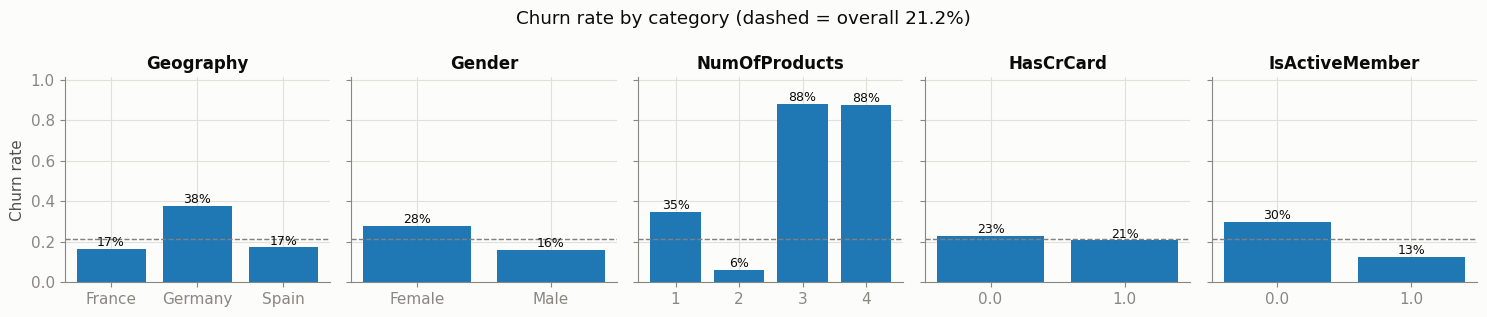

In [42]:
cat_cols = ["Geography", "Gender", "NumOfProducts", "HasCrCard", "IsActiveMember"]
overall = train["Exited"].mean()
fig, axes = plt.subplots(1, 5, figsize=(15, 3.2), sharey=True)
for ax, col in zip(axes, cat_cols):
    rate = train.groupby(col)["Exited"].mean()
    ax.bar(rate.index.astype(str), rate.values)
    ax.axhline(overall, color="gray", linestyle="--", linewidth=1)
    for i, v in enumerate(rate.values):
        ax.annotate(f"{v:.0%}", (i, v), ha="center", va="bottom", fontsize=9)
    ax.set_title(col)
    ax.margins(y=0.15)
axes[0].set_ylabel("Churn rate")
fig.suptitle(f"Churn rate by category (dashed = overall {overall:.1%})")
plt.tight_layout()
plt.show()

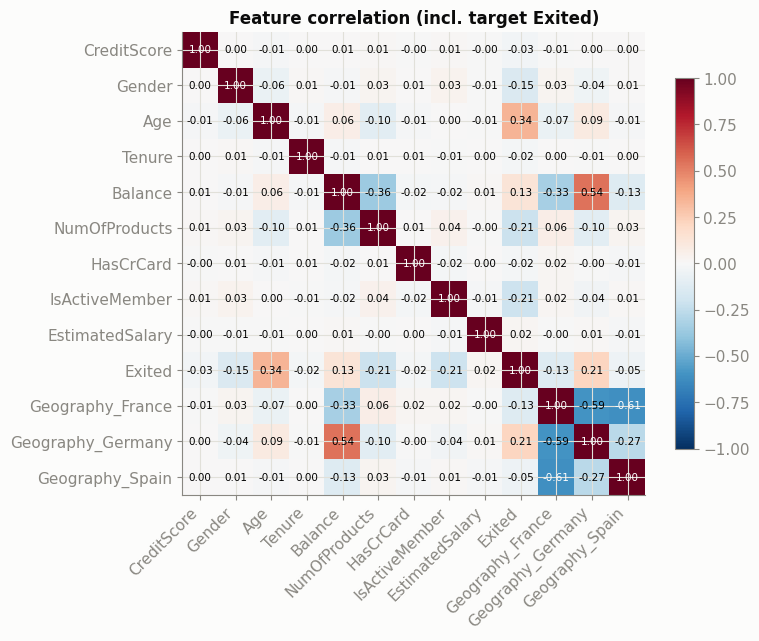

In [ ]:
enc = train.drop(columns=["id", "CustomerId", "Surname"]).copy()
enc["Gender"] = (enc["Gender"] == "Male").astype(int)
enc = pd.get_dummies(enc, columns=["Geography"], dtype=int)
corr = enc.corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr)), corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7.5,
                color="white" if abs(v) > 0.6 else "black")
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Feature correlation (include target Exited)")
plt.tight_layout()
plt.show()

In [47]:
# Balance 分成 Zero / Positive 兩組,和 Geography 交叉看 Exited
tmp = train.assign(BalanceGroup=np.where(train["Balance"] == 0, "Zero", "Positive"))
churn = tmp.pivot_table(index="Geography", columns="BalanceGroup",
                        values="Exited", aggfunc="mean")
n = tmp.pivot_table(index="Geography", columns="BalanceGroup",
                    values="Exited", aggfunc="size")
print("流失率:")
print(churn.round(3))
print("\n樣本數:")
print(n)

流失率:
BalanceGroup  Positive   Zero
Geography                    
France           0.175  0.161
Germany          0.380  0.204
Spain            0.190  0.163

樣本數:
BalanceGroup  Positive   Zero
Geography                    
France           28997  65218
Germany          34493    113
Spain            11896  24317


### EDA 發現
- **Age** : 平均而言, Exited 者 Age 較高
- **NumOfProducts 非單調成長（非線性pattern）**:1個產品流失率僅 35%,2 個產品流失率僅 6%,3–4 個產品高達 88%。
- **解釋變數間相關性**:從correlation 可以看到德國 × Balance correlation 為高相關（>0.5）,近一步確認看到德國且balance positive的exit rate較高
- **CreditScore /Balanced / EstimatedSalary /Tenure/ HasCrCard**:Exit and non-exied 於這些解釋變數的分布上幾乎重疊

Based on EDA Findings, 有發現非線性的pattern以及存在解釋變數間具相關性故挑選無母數模型來訓練,另外本次資料集有16萬筆是足夠多的數量,所以選擇XGboost model 來進行此分類任務

## 2. 從 training data 切分出 training set & vilidation set,用training set(訓練集)資料進行訓練並用vilidation set（驗證集）評估模型表現

### 模型選擇依據(由資料特性推導)


### 驗證架構

1. **Stratified 80/20 切分**:80% 訓練 / 20% 驗證——所有評估指標與曲線都算在**驗證集**上(模型訓練時沒看過)
2. test.csv **無標籤**,不能用於評估
3. 最終用**全部 train** 以相同超參數重訓 → 預測 test.csv 的流失機率

In [49]:
%pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 333.3 kB/s  0:00:06 eta 0:00:01

[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Split testing set & vilidation set
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             confusion_matrix, roc_curve, precision_recall_curve,
                             classification_report)
from xgboost import XGBClassifier

ID_COLS, TARGET = ["id", "CustomerId", "Surname"], "Exited"
CAT_COLS = ["Geography", "Gender"]

X = train.drop(columns=ID_COLS + [TARGET]).copy()
X[CAT_COLS] = X[CAT_COLS].astype("category")
y = train[TARGET]

X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
# stratify=y:按 Exited 的比例分層抽樣,保證切完兩邊的流失率都維持 21.16%
print(f"訓練集: {len(X_tr):,} 筆(流失率 {y_tr.mean():.4f})")
print(f"驗證集: {len(X_val):,} 筆(流失率 {y_val.mean():.4f})")

訓練集: 132,027 筆(流失率 0.2116)
驗證集: 33,007 筆(流失率 0.2116)


In [70]:
%%time
XGB_PARAMS = dict(
    n_estimators=300, learning_rate=0.1, max_depth=6,
    tree_method="hist", enable_categorical=True,
    random_state=42, n_jobs=-1,
    eval_metric=["logloss", "auc"],
)

model = XGBClassifier(**XGB_PARAMS)
model.fit(X_tr, y_tr, eval_set=[(X_tr, y_tr), (X_val, y_val)], verbose=False)
proba_val = model.predict_proba(X_val)[:, 1]

print(f"Validation ROC AUC: {roc_auc_score(y_val, proba_val):.4f}")
print(f"Validation F1@0.5 : {f1_score(y_val, (proba_val >= 0.5).astype(int)):.4f}")
print(f"Validation F1@0.35(0.35為本任務挑選門檻值) : {f1_score(y_val, (proba_val >= 0.35).astype(int)):.4f}")


Validation ROC AUC: 0.8885
Validation F1@0.5 : 0.6382
Validation F1@0.35(0.35為本任務挑選門檻值) : 0.6662
CPU times: user 6.64 s, sys: 2.22 s, total: 8.86 s
Wall time: 4.89 s


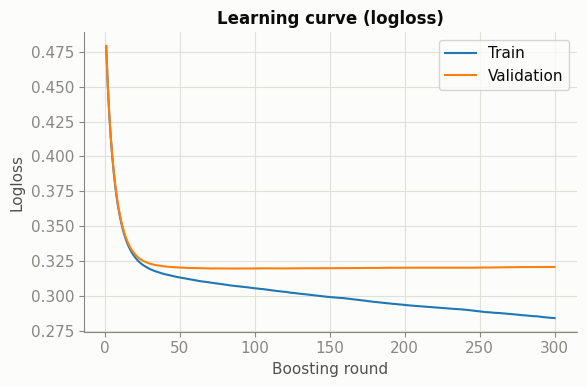

In [72]:
hist = model.evals_result()   # validation_0 = 訓練集, validation_1 = 驗證集
rounds = range(1, len(hist["validation_0"]["logloss"]) + 1)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(rounds, hist["validation_0"]["logloss"], label="Train")
ax.plot(rounds, hist["validation_1"]["logloss"], label="Validation")
ax.set_xlabel("Boosting round")
ax.set_ylabel("Logloss")
ax.set_title("Learning curve (logloss)")
ax.legend()
plt.tight_layout()
plt.show()


接下來由vilidation set（驗證集）的資料用f1-score的表現來決定模型預測機率的決策門檻值以及選取門檻值下的confusion matrix

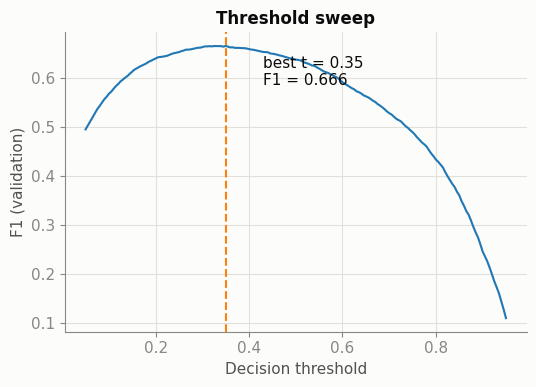

,Pred: Stayed,Pred: Exited,Total
True: Stayed,23627,2396,26023
True: Exited,2299,4685,6984
Total,25926,7081,33007


,Pred: Stayed,Pred: Exited
True: Stayed,0.908,0.092
True: Exited,0.329,0.671


In [73]:
thresholds = np.linspace(0.05, 0.95, 181)
f1s = np.array([f1_score(y_val, (proba_val >= t).astype(int)) for t in thresholds])
best_t = thresholds[f1s.argmax()]

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.plot(thresholds, f1s)
ax.axvline(best_t, color="C1", linestyle="--")
ax.annotate(f"best t = {best_t:.2f}\nF1 = {f1s.max():.3f}",
            (best_t, f1s.max()), xytext=(best_t + 0.08, f1s.max() - 0.08))
ax.set_xlabel("Decision threshold")
ax.set_ylabel("F1 (validation)")
ax.set_title("Threshold sweep")
plt.tight_layout()
plt.show()

# 混淆矩陣 — 筆數表(含加總)
y_pred = (proba_val >= best_t).astype(int)
cm_table = pd.DataFrame(confusion_matrix(y_val, y_pred),
                        index=["True: Stayed", "True: Exited"],
                        columns=["Pred: Stayed", "Pred: Exited"])
cm_table["Total"] = cm_table.sum(axis=1)
cm_table.loc["Total"] = cm_table.sum()
display(cm_table)

# 混淆矩陣
cm_pct = pd.DataFrame(confusion_matrix(y_val, y_pred, normalize="true"),
                      index=["True: Stayed", "True: Exited"],
                      columns=["Pred: Stayed", "Pred: Exited"]).round(3)
display(cm_pct)

## 4.將訓練好的模型來預測 testing data 資料的 Exited 機率跟預測結果並連同 F1 score & confusion matrix 整理出 csv

In [76]:
# 最終:用全部 train(165k)以相同超參數重訓 → 預測 test.csv
final_model = XGBClassifier(**XGB_PARAMS)
final_model.fit(X, y)

X_test = test.drop(columns=ID_COLS).copy()
X_test[CAT_COLS] = X_test[CAT_COLS].astype("category")
proba_test = final_model.predict_proba(X_test)[:, 1]

# 輸出 = 原始 test.csv + 兩個新欄位:流失機率、門檻 0.35 下的分類
output = test.copy()
output["Exited_Prob"] = proba_test.round(4)
output["Exited_Pred"] = (proba_test >= best_t).astype(int)
output.to_csv("predictions.csv", index=False)

print(f"已輸出 predictions.csv({len(output):,} 筆)")
print(f"門檻 {best_t:.2f} 下判為流失: {output['Exited_Pred'].sum():,} 筆 "
      f"({output['Exited_Pred'].mean():.1%})")
output.head()

已輸出 predictions.csv(110,023 筆)
門檻 0.35 下判為流失: 24,069 筆 (21.9%)


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited_Prob,Exited_Pred
0,165034,15773898,Lucchese,586,France,Female,23.0,2,0.00,2,0.0,1.0,160976.75,0.0317,0
1,165035,15782418,Nott,683,France,Female,46.0,2,0.00,1,1.0,0.0,72549.27,0.8475,1
2,165036,15807120,K?,656,France,Female,34.0,7,0.00,2,1.0,0.0,138882.09,0.0264,0
3,165037,15808905,O'Donnell,681,France,Male,36.0,8,0.00,1,1.0,0.0,113931.57,0.2662,0
4,165038,15607314,Higgins,752,Germany,Male,38.0,10,121263.62,1,1.0,0.0,139431.00,0.3533,1


In [82]:
# 輸出模型評估 CSV(驗證集上的結果)
from sklearn.metrics import precision_score, recall_score, accuracy_score

y_pred = (proba_val >= best_t).astype(int)

# 1) metrics.csv — 各項指標
metrics = pd.DataFrame([
    ["Evaluated_on",       "validation set (20% of train, 33,007 rows)"],
    ["ROC_AUC",            round(roc_auc_score(y_val, proba_val), 4)],
    ["Decision_threshold", best_t],
    ["F1",                 round(f1_score(y_val, y_pred), 4)],
    ["Precision",          round(precision_score(y_val, y_pred), 4)],
    ["Recall",             round(recall_score(y_val, y_pred), 4)],
    ["Accuracy",           round(accuracy_score(y_val, y_pred), 4)],
], columns=["metric", "value"])
metrics.to_csv("metrics.csv", index=False)

# 2) confusion_matrix.csv — 2×2 表格,行列都有標籤
cm_table = pd.DataFrame(confusion_matrix(y_val, y_pred),
                        index=["True: Stayed", "True: Exited"],
                        columns=["Pred: Stayed", "Pred: Exited"])
cm_table.to_csv("confusion_matrix.csv")

print("已輸出 metrics.csv、confusion_matrix.csv")
display(metrics)
display(cm_table)



已輸出 metrics.csv、confusion_matrix.csv


,metric,value
0,Evaluated_on,"validation set (20% of train, 33,007 rows)"
1,ROC_AUC,0.8885
2,Decision_threshold,0.35
3,F1,0.6662
4,Precision,0.6616
5,Recall,0.6708
6,Accuracy,0.8578


,Pred: Stayed,Pred: Exited
True: Stayed,23627,2396
True: Exited,2299,4685
